**Mô Hình 2: Baseline U-Net Cải Tiến (Mô hình so sánh)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U albumentations
!pip install -q -U timm
!pip install -q -U opencv-python-headless
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
import sys, os

PROJECT_ROOT = "/content/drive/MyDrive/DFUTissueSegNet"
CODES_DIR    = PROJECT_ROOT + "/Codes"

sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, CODES_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CODES_DIR   :", CODES_DIR)

PROJECT_ROOT: /content/drive/MyDrive/DFUTissueSegNet
CODES_DIR   : /content/drive/MyDrive/DFUTissueSegNet/Codes


In [ ]:
import cv2
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from datetime import datetime
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import albumentations as albu
!pip install -q -U pretrainedmodels
!pip install -q -U efficientnet_pytorch
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.utils import losses, base

warnings.filterwarnings('ignore')
%matplotlib inline

print('torch     :', torch.__version__)
print('smp       :', smp.__version__)
print('albument. :', albu.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
torch     : 2.11.0+cu128
smp       : 0.3.3
albument. : 2.0.8


## Parameters

In [ ]:
# ================================================================
#  MODEL
# ================================================================
BASE_MODEL       = 'UNet_resnet50_improved'
ENCODER          = 'resnet50'      # mạnh hơn resnet34, vẫn nhẹ hơn MiT-B3
ENCODER_WEIGHTS  = 'imagenet'

# ================================================================
#  DATA
# ================================================================
BATCH_SIZE     = 16        # giảm vì resnet50 nặng hơn resnet34
n_classes      = 4
RESIZE         = (256, 256)
TO_CATEGORICAL = True

# ================================================================
#  TRAINING
# ================================================================
ACTIVATION   = 'softmax'
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LR           = 1e-4
WEIGHT_DECAY = 1e-4      # tăng nhẹ để regularize tốt hơn
EPOCHS       = 300

SAVE_BEST_MODEL  = True
SAVE_LAST_MODEL  = False
SAVE_WEIGHTS_ONLY = True
PERIOD           = 10
RAW_PREDICTION   = False

EARLY_STOP = True
PATIENCE   = 40

# ================================================================
#  FOCAL LOSS
# ================================================================
FOCAL_GAMMA = 2.0   # gamma càng lớn → tập trung class khó (label 1) càng nhiều

print(f'Device  : {DEVICE}')
print(f'Encoder : {ENCODER}')

Device  : cuda
Encoder : resnet50


## Helper functions

In [ ]:
def read_names(txt_file, ext='.png'):
    with open(txt_file, 'r') as f:
        names = f.readlines()
    names = [n.strip('\n') + ext for n in names]
    return names


def fix_case_filenames(img_dir, names):
    real_files = {f.lower(): f for f in os.listdir(img_dir)}
    fixed = []
    for n in names:
        if n.lower() in real_files:
            fixed.append(real_files[n.lower()])
        else:
            raise FileNotFoundError(f'❌ File {n} not found in {img_dir}')
    return fixed


def save_checkpoint(model_path, epoch, model_state_dict, optimizer_state_dict):
    state = {
        'epoch'     : epoch + 1,
        'state_dict': deepcopy(model_state_dict),
        'optimizer' : deepcopy(optimizer_state_dict),
    }
    torch.save(state, model_path)


# ================================================================
#  Tính class weight tự động từ toàn bộ training masks
#  → giải quyết class imbalance (label 1 bị bỏ qua)
# ================================================================
def compute_class_weights(mask_dir, names, n_classes=4, device='cpu'):
    print('⏳ Đang tính class weights từ training masks...')
    counts = np.zeros(n_classes, dtype=np.float64)
    for name in names:
        mask = cv2.imread(os.path.join(mask_dir, name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        for c in range(n_classes):
            counts[c] += np.sum(mask == c)

    total = counts.sum()
    # inverse-frequency weighting
    weights = total / (n_classes * (counts + 1e-6))
    # normalize: trung bình = 1
    weights = weights / weights.mean()

    print('Class pixel counts :', counts.astype(int))
    print('Class weights       :', np.round(weights, 4))
    return torch.tensor(weights, dtype=torch.float32).to(device)

## Dataset

In [ ]:
class Dataset(torch.utils.data.Dataset):

    def __init__(
        self,
        list_IDs,
        images_dir,
        masks_dir,
        augmentation=None,
        preprocessing=None,
        to_categorical=False,
        resize=(256, 256),
        n_classes=4,
        default_img=None,
        default_mask=None,
    ):
        self.ids          = list_IDs
        self.images_fps   = [os.path.join(images_dir, i) for i in list_IDs]
        self.masks_fps    = [os.path.join(masks_dir,  i) for i in list_IDs]
        self.augmentation  = augmentation
        self.preprocessing = preprocessing
        self.to_categorical = to_categorical
        self.resize        = resize
        self.n_classes     = n_classes
        self.default_img   = default_img
        self.default_mask  = default_mask

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        image = cv2.imread(self.images_fps[i])
        mask  = cv2.imread(self.masks_fps[i],  cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            image = self.default_img.copy()
            mask  = self.default_mask.copy()
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, self.resize, interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  self.resize, interpolation=cv2.INTER_NEAREST)

        # clip mask về đúng range để tránh lỗi one-hot
        mask = np.clip(mask, 0, self.n_classes - 1)

        mask = np.expand_dims(mask, axis=-1)   # (H,W) → (H,W,1)

        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.to_categorical:
            mask = mask.squeeze(0).astype('int64')          # (H,W)
            mask = np.eye(self.n_classes)[mask]             # (H,W,C)
            mask = np.transpose(mask, (2, 0, 1)).astype('float32')  # (C,H,W)

        return image, mask

## Augmentation

Thêm `ElasticTransform` và `CoarseDropout` so với baseline cũ để model robust hơn với vết thương có hình dạng bất thường.

In [ ]:
def get_training_augmentation():
    train_transform = [

        # Flip
        albu.OneOf([
            albu.HorizontalFlip(p=0.5),
            albu.VerticalFlip(p=0.5),
        ], p=0.8),

        # Geometric
        albu.OneOf([
            albu.ShiftScaleRotate(scale_limit=0.5,  rotate_limit=0,  shift_limit=0,   p=0.1, border_mode=0),
            albu.ShiftScaleRotate(scale_limit=0,    rotate_limit=30, shift_limit=0,   p=0.1, border_mode=0),
            albu.ShiftScaleRotate(scale_limit=0,    rotate_limit=0,  shift_limit=0.1, p=0.6, border_mode=0),
            albu.ShiftScaleRotate(scale_limit=0.5,  rotate_limit=30, shift_limit=0.1, p=0.2, border_mode=0),
        ], p=0.9),

        # ✅ MỚI: Elastic transform — giúp model học được biên dạng vết thương phức tạp
        albu.ElasticTransform(
            alpha=120, sigma=6, p=0.3
        ),

        # Noise / Blur
        albu.OneOf([
            albu.Perspective(p=0.2),
            albu.GaussNoise(p=0.2),
            albu.Sharpen(p=0.2),
            albu.Blur(blur_limit=3, p=0.2),
            albu.MotionBlur(blur_limit=3, p=0.2),
        ], p=0.5),

        # Color
        albu.OneOf([
            albu.CLAHE(p=0.25),
            albu.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.25),
            albu.RandomGamma(p=0.25),
            albu.HueSaturationValue(p=0.25),
        ], p=0.3),

        # ✅ MỚI: CoarseDropout — giả lập vùng bị che khuất, giúp model không overfit
        albu.CoarseDropout(
            max_holes=8, max_height=16, max_width=16,
            min_holes=1, min_height=8,  min_width=8,
            fill_value=0, p=0.2
        ),

    ]
    return albu.Compose(train_transform, p=0.9)


def get_validation_augmentation():
    return albu.Compose([])


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn):
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=to_tensor, mask=to_tensor),
    ]
    return albu.Compose(_transform)

## Custom Focal Loss

Focal Loss phạt nặng hơn các pixel bị predict sai trên class thiểu số (label 1). Kết hợp với class_weights để xử lý triệt để class imbalance.

In [ ]:
class WeightedFocalLoss(nn.Module):
    """
    Focal Loss cho multiclass segmentation với class weights.
    Input : pred  (B, C, H, W) — logits hoặc softmax probs
            target (B, C, H, W) — one-hot float32
    """
    def __init__(self, gamma=2.0, weight=None, eps=1e-6):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight   # Tensor shape (C,)
        self.eps    = eps

    def forward(self, pred, target):
        # pred: (B,C,H,W) sau softmax  |  target: (B,C,H,W) one-hot
        if pred.shape != target.shape:
            raise ValueError(f'Shape mismatch: pred {pred.shape} vs target {target.shape}')

        pred    = pred.clamp(self.eps, 1.0 - self.eps)
        log_p   = torch.log(pred)                         # (B,C,H,W)
        focal_w = (1.0 - pred) ** self.gamma              # (B,C,H,W)
        loss    = -focal_w * log_p * target               # (B,C,H,W)

        if self.weight is not None:
            # broadcast class weights: (C,) → (1,C,1,1)
            w = self.weight.view(1, -1, 1, 1).to(pred.device)
            loss = loss * w

        return loss.mean()


# Wrapper để tương thích với smp SumOfLosses
class FocalLossWrapper(base.Loss, nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        nn.Module.__init__(self) # Initialize nn.Module first
        super().__init__(name='focal_loss') # Then base.Loss.__init__
        self._loss    = WeightedFocalLoss(gamma=gamma, weight=weight)

    def forward(self, pred, target):
        return self._loss(pred, target)

## Setup paths & tính class weights

In [ ]:
BASE_DATASET = os.path.join(PROJECT_ROOT, 'DFUTissue', 'Labeled', 'Padded')

x_train_dir = os.path.join(BASE_DATASET, 'Images',      'TrainVal')
y_train_dir = os.path.join(BASE_DATASET, 'Annotations', 'TrainVal')
x_valid_dir = x_train_dir
y_valid_dir = y_train_dir
x_test_dir  = os.path.join(BASE_DATASET, 'Images',      'Test')
y_test_dir  = os.path.join(BASE_DATASET, 'Annotations', 'Test')

dir_txt        = os.path.join(PROJECT_ROOT, 'DFUTissue', 'Labeled')
list_IDs_train = read_names(os.path.join(dir_txt, 'labeled_train_names.txt'), ext='.png')
list_IDs_val   = read_names(os.path.join(dir_txt, 'labeled_val_names.txt'),   ext='.png')
list_IDs_test  = read_names(os.path.join(dir_txt, 'test_names.txt'),          ext='.png')

print('Train :', len(list_IDs_train))
print('Val   :', len(list_IDs_val))
print('Test  :', len(list_IDs_test))

# ✅ Tính class weights từ training set
class_weights = compute_class_weights(y_train_dir, list_IDs_train, n_classes=n_classes, device=DEVICE)

Train : 78
Val   : 16
Test  : 16
⏳ Đang tính class weights từ training masks...
Class pixel counts : [4719842   52037  103758  236171]
Class weights       : [0.0254 2.3083 1.1577 0.5086]


## Build model, loss, optimizer

In [ ]:
seed = random.randint(0, 5000)
print(f'seed: {seed}')
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# ================================================================
#  MODEL — Vanilla U-Net, không có attention
#  Chỉ thay encoder resnet34 → resnet50 để có capacity tốt hơn
# ================================================================
model = smp.Unet(
    encoder_name          = ENCODER,
    encoder_weights       = ENCODER_WEIGHTS,
    classes               = n_classes,
    activation            = ACTIVATION,
    decoder_attention_type= None,   # vanilla — không pscSE
)
model.to(DEVICE)

preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

# ================================================================
#  LOSS
#  ✅ Dice + Weighted Focal (thay CE thuần)
#     Dice   : xử lý imbalance tốt ở cấp độ region
#     Focal  : phạt nặng class khó (label 1) ở cấp độ pixel
# ================================================================
dice_loss  = losses.DiceLoss()
focal_loss = FocalLossWrapper(gamma=FOCAL_GAMMA, weight=class_weights)
total_loss = base.SumOfLosses(dice_loss, focal_loss)

metrics_list = [
    smp.utils.metrics.IoU(threshold=0.5),
    smp.utils.metrics.Fscore(threshold=0.5),
]

# ================================================================
#  OPTIMIZER + SCHEDULER
#  ✅ AdamW (weight decay tách biệt khỏi gradient) thay Adam
#  ✅ CosineAnnealingWarmRestarts: tránh stuck local minima
# ================================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# T_0: restart sau mỗi 50 epoch, T_mult=2: mỗi lần restart chu kỳ nhân đôi
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel params : {total_params/1e6:.1f}M')
print(f'Loss         : DiceLoss + WeightedFocalLoss(gamma={FOCAL_GAMMA})')
print(f'Optimizer    : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler    : CosineAnnealingWarmRestarts T0=50 Tmult=2')

seed: 2174
Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 302MB/s]



Model params : 75.9M
Loss         : DiceLoss + WeightedFocalLoss(gamma=2.0)
Optimizer    : AdamW  lr=0.0001  wd=0.0001
Scheduler    : CosineAnnealingWarmRestarts T0=50 Tmult=2


## Dataloader

In [ ]:
random.shuffle(list_IDs_train)

DEFAULT_IMG_TRAIN  = cv2.cvtColor(cv2.imread(os.path.join(x_train_dir, list_IDs_train[0])), cv2.COLOR_BGR2RGB)
DEFAULT_MASK_TRAIN = cv2.imread(os.path.join(y_train_dir, list_IDs_train[0]), 0)
DEFAULT_IMG_VAL    = cv2.cvtColor(cv2.imread(os.path.join(x_valid_dir, list_IDs_val[0])),   cv2.COLOR_BGR2RGB)
DEFAULT_MASK_VAL   = cv2.imread(os.path.join(y_valid_dir, list_IDs_val[0]), 0)

train_dataset = Dataset(
    list_IDs_train, x_train_dir, y_train_dir,
    augmentation  = get_training_augmentation(),
    preprocessing = get_preprocessing(preprocessing_fn),
    to_categorical= TO_CATEGORICAL,
    resize=RESIZE, n_classes=n_classes,
    default_img=DEFAULT_IMG_TRAIN, default_mask=DEFAULT_MASK_TRAIN,
)

valid_dataset = Dataset(
    list_IDs_val, x_valid_dir, y_valid_dir,
    augmentation  = get_validation_augmentation(),
    preprocessing = get_preprocessing(preprocessing_fn),
    to_categorical= TO_CATEGORICAL,
    resize=RESIZE, n_classes=n_classes,
    default_img=DEFAULT_IMG_VAL, default_mask=DEFAULT_MASK_VAL,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(valid_loader)}')

Train batches : 5
Val   batches : 1


## Training

In [ ]:
USE_TTA = False # Set to True if you want to use Test Time Augmentation

In [ ]:
model_name     = BASE_MODEL + '_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
checkpoint_loc = os.path.join(PROJECT_ROOT, 'checkpoints', model_name)
os.makedirs(checkpoint_loc, exist_ok=True)
print('Model name :', model_name)

train_epoch = smp.utils.train.TrainEpoch(
    model, loss=total_loss, metrics=metrics_list,
    optimizer=optimizer, device=DEVICE, verbose=True,
)
valid_epoch = smp.utils.train.ValidEpoch(
    model, loss=total_loss, metrics=metrics_list,
    device=DEVICE, verbose=True,
)

best_viou    = 0.0
best_vloss   = 1_000_000.
save_model   = False
cnt_patience = 0
best_model_epoch = 0

store_train_loss, store_val_loss   = [], []
store_train_iou,  store_val_iou    = [], []
store_train_dice, store_val_dice   = [], []
store_lr                           = []

for epoch in range(EPOCHS):

    current_lr = optimizer.param_groups[0]['lr']
    print(f'\nEpoch {epoch:04d}  |  LR = {current_lr:.2e}')

    train_logs = train_epoch.run(train_loader)
    valid_logs = valid_epoch.run(valid_loader)

    train_loss_key = list(train_logs.keys())[0]
    val_loss_key   = list(valid_logs.keys())[0]

    store_train_loss.append(train_logs[train_loss_key])
    store_val_loss.append(valid_logs[val_loss_key])
    store_train_iou.append(train_logs['iou_score'])
    store_val_iou.append(valid_logs['iou_score'])
    store_train_dice.append(train_logs['fscore'])
    store_val_dice.append(valid_logs['fscore'])
    store_lr.append(current_lr)

    improved = False
    if valid_logs[val_loss_key] < best_vloss:
        best_vloss = valid_logs[val_loss_key]
        improved   = True
        print(f'  ✅ Val loss ↓  → {best_vloss:.4f}  (epoch {epoch:04d})')

    if valid_logs['iou_score'] > best_viou:
        best_viou = valid_logs['iou_score']
        improved  = True
        print(f'  ✅ Val IoU  ↑  → {best_viou:.4f}  (epoch {epoch:04d})')

    if improved:
        cnt_patience     = 0
        best_model_epoch = epoch
        save_checkpoint(
            os.path.join(checkpoint_loc, 'best_model.pth'),
            epoch, model.state_dict(), optimizer.state_dict()
        )
    else:
        cnt_patience += 1

    # Scheduler step
    scheduler.step(epoch)

    if EARLY_STOP and cnt_patience >= PATIENCE:
        print(f'\n⛔ Early stopping at epoch {epoch:04d}  (patience={PATIENCE})')
        break

    if not SAVE_BEST_MODEL and (epoch + 1) % PERIOD == 0:
        save_checkpoint(
            os.path.join(checkpoint_loc, f'cp-{epoch+1:04d}.pth'),
            epoch, model.state_dict(), optimizer.state_dict()
        )

if not EARLY_STOP and SAVE_LAST_MODEL:
    save_checkpoint(
        os.path.join(checkpoint_loc, 'last_model.pth'),
        epoch, model.state_dict(), optimizer.state_dict()
    )

print(f'\n🏆 Best model epoch : {best_model_epoch}')

Model name : UNet_resnet50_improved_2026-06-09_19-54-48

Epoch 0000  |  LR = 1.00e-04
valid: 100%|██████████| 1/1 [00:12<00:00, 12.47s/it, dice_loss + focal_loss - 0.9591, iou_score - 0.01093, fscore - 0.02162]
  ✅ Val loss ↓  → 0.9591  (epoch 0000)
  ✅ Val IoU  ↑  → 0.0109  (epoch 0000)

Epoch 0001  |  LR = 1.00e-04
valid: 100%|██████████| 1/1 [00:00<00:00,  1.87it/s, dice_loss + focal_loss - 0.8567, iou_score - 0.008228, fscore - 0.01632]
  ✅ Val loss ↓  → 0.8567  (epoch 0001)

Epoch 0002  |  LR = 9.99e-05
valid: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s, dice_loss + focal_loss - 0.7767, iou_score - 0.008591, fscore - 0.01704]
  ✅ Val loss ↓  → 0.7767  (epoch 0002)

Epoch 0003  |  LR = 9.96e-05
valid: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s, dice_loss + focal_loss - 0.7327, iou_score - 0.01165, fscore - 0.02303]
  ✅ Val loss ↓  → 0.7327  (epoch 0003)
  ✅ Val IoU  ↑  → 0.0116  (epoch 0003)

Epoch 0004  |  LR = 9.91e-05
valid: 100%|██████████| 1/1 [00:00<00:00,  1.96it/s, dice_

## Plot loss & metric curves

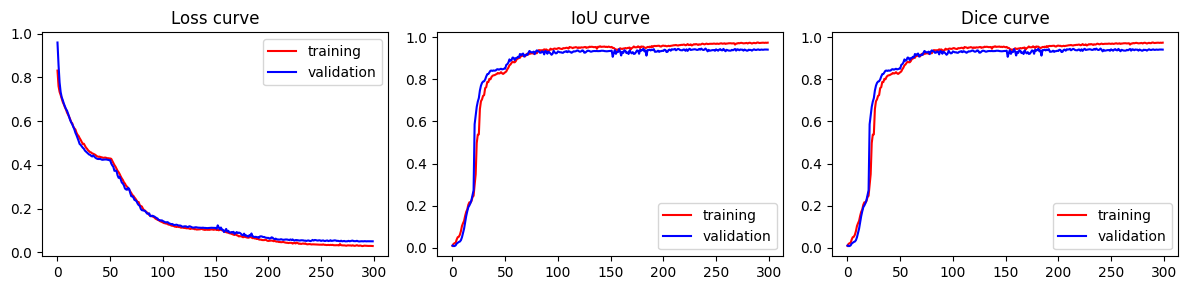

In [ ]:
# Plot loss curves =============================================================
fig, ax = plt.subplots(1,3, figsize=(12, 3))

ax[0].plot(store_train_loss, 'r')
ax[0].plot(store_val_loss, 'b')
ax[0].set_title('Loss curve')
ax[0].legend(['training', 'validation'])

ax[1].plot(store_train_iou, 'r')
ax[1].plot(store_val_iou, 'b')
ax[1].set_title('IoU curve')
ax[1].legend(['training', 'validation'])

ax[2].plot(store_train_iou, 'r')
ax[2].plot(store_val_iou, 'b')
ax[2].set_title('Dice curve')
ax[2].legend(['training', 'validation'])

fig.tight_layout()

save_fig_dir = "/content/drive/MyDrive/Wound_tissue_segmentation/plots/"
if not os.path.exists(save_fig_dir): os.makedirs(save_fig_dir)

fig.savefig(os.path.join(save_fig_dir, model_name + '.png'))

## Inference & Evaluation

In [ ]:
# ================================================================
#  COPY CELL NÀY VÀO NOTEBOOK CHÍNH, THAY THẾ CELL INFERENCE CŨ
# ================================================================

import torch
import os
import cv2
import numpy as np
import json
import warnings
from PIL import Image
warnings.filterwarnings('ignore')

# Load best model
checkpoint = torch.load(os.path.join(checkpoint_loc, 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
print(f'✅ Loaded best model từ epoch {checkpoint["epoch"]}')

# Test dataset
test_dataset = Dataset(
    list_IDs_test, x_test_dir, y_test_dir,
    augmentation   = get_validation_augmentation(),
    preprocessing  = get_preprocessing(preprocessing_fn),
    resize         = RESIZE,
    to_categorical = False,
    n_classes      = n_classes,
    # copypaste_bank = None,
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

# Save dirs
save_dir_pred         = os.path.join(PROJECT_ROOT, 'predictions',             model_name)
save_dir_pred_pal     = os.path.join(PROJECT_ROOT, 'predictions_palette',     model_name)
save_dir_pred_pal_cat = os.path.join(PROJECT_ROOT, 'predictions_palette_cat', model_name)
for d in [save_dir_pred, save_dir_pred_pal, save_dir_pred_pal_cat]:
    os.makedirs(d, exist_ok=True)

palette = [[0,0,0],[255,0,0],[0,255,0],[0,0,255]]
ep      = 1e-6

# ================================================================
#  Lưu metric theo 2 cách:
#  metric_raw  : giống cũ (kể cả FP-only)
#  metric_clean: chỉ tính khi GT có label đó
# ================================================================
metric_raw   = {}   # để save JSON (giữ nguyên như cũ)
metric_clean = {}   # để tính per-class summary đúng

# Dataset-level counters (giữ nguyên — vẫn đúng)
stp = sfp = sfn = 0

# Per-class counters CHỈ tính khi GT có label đó
# class_tp[c], class_fp[c], class_fn[c]
class_tp = {c: 0 for c in range(1, n_classes)}
class_fp = {c: 0 for c in range(1, n_classes)}
class_fn = {c: 0 for c in range(1, n_classes)}
class_n  = {c: 0 for c in range(1, n_classes)}  # số ảnh GT có label c

iter_loader = iter(test_loader)

for idx in range(len(list_IDs_test)):

    tp = fp = fn = 0
    name = os.path.splitext(list_IDs_test[idx])[0]
    metric_raw[name]   = {}
    metric_clean[name] = {}

    image, gt_mask = next(iter_loader)

    # Predict (TTA nếu bật)
    if USE_TTA:
        pr_prob = predict_with_tta(model, image, DEVICE)
    else:
        with torch.no_grad():
            pr_prob = model.predict(image.to(DEVICE))

    pr_mask = torch.argmax(pr_prob, dim=1)

    gt_mask = gt_mask.squeeze().cpu().numpy().astype(np.int64)
    pred    = pr_mask.squeeze().cpu().numpy()

    # Save ảnh
    cv2.imwrite(os.path.join(save_dir_pred, list_IDs_test[idx]),
                pred.astype(np.uint8))

    pal_gt = Image.fromarray(gt_mask.astype(np.uint8)).convert('P')
    pal_gt.putpalette(np.array(palette, dtype=np.uint8))

    pal_pr = Image.fromarray(pred.astype(np.uint8)).convert('P')
    pal_pr.putpalette(np.array(palette, dtype=np.uint8))
    pal_pr.save(os.path.join(save_dir_pred_pal, list_IDs_test[idx]))

    cat = Image.new('RGB', (pal_gt.width * 2, pal_gt.height), 'white')
    cat.paste(pal_gt, (0, 0))
    cat.paste(pal_pr, (pal_gt.width, 0))
    cat.save(os.path.join(save_dir_pred_pal_cat, list_IDs_test[idx]))

    # ==============================================================
    #  Tính metrics
    # ==============================================================
    lbl_gt   = set(np.unique(gt_mask)) - {0}
    lbl_pred = set(np.unique(pred))    - {0}

    # --- FP only: model predict nhầm, GT không có ---
    for d in (lbl_pred - lbl_gt):
        fp_pixels = len(np.argwhere(pred == d))
        fp += fp_pixels
        # ✅ KHÔNG đưa vào per-class summary vì GT không có label này
        # Nhưng vẫn tính vào dataset-level sfp
        metric_raw[name][str(d)] = [0, 0, 0, 0]
        print(f'{idx+1:3d} {name}: label {d} | ⚠️  FP only (GT không có label này)')

    # --- FN only: GT có nhưng model không predict ---
    for d in (lbl_gt - lbl_pred):
        fn_pixels = len(np.argwhere(gt_mask == d))
        fn += fn_pixels
        metric_raw[name][str(d)]   = [0, 0, 0, 0]
        metric_clean[name][str(d)] = [0, 0, 0, 0]

        # ✅ Tính vào per-class vì GT CÓ label này
        if d in class_fn:
            class_fn[d] += fn_pixels
            class_n[d]  += 1

        print(f'{idx+1:3d} {name}: label {d} | P:  0.00 R:  0.00 Dice:  0.00 IoU:  0.00  (GT có, model bỏ sót)')

    # --- Intersection: cả GT và predict đều có ---
    for c in (lbl_gt & lbl_pred):
        gt_set   = set(zip(*np.where(gt_mask == c)))
        pred_set = set(zip(*np.where(pred    == c)))

        tp_ = len(gt_set & pred_set)
        fp_ = len(pred_set - gt_set)
        fn_ = len(gt_set  - pred_set)

        tp += tp_; fp += fp_; fn += fn_

        p_    = tp_ / (tp_ + fp_ + ep) * 100
        r_    = tp_ / (tp_ + fn_ + ep) * 100
        dice_ = 2*tp_ / (2*tp_ + fp_ + fn_ + ep) * 100
        iou_  = tp_ / (tp_ + fp_ + fn_ + ep) * 100

        print(f'{idx+1:3d} {name}: label {c} | P:{p_:6.2f} R:{r_:6.2f} Dice:{dice_:6.2f} IoU:{iou_:6.2f}')

        metric_raw[name][str(c)]   = [p_, r_, dice_, iou_]
        metric_clean[name][str(c)] = [p_, r_, dice_, iou_]

        # ✅ Tính vào per-class vì GT CÓ label này
        if c in class_tp:
            class_tp[c] += tp_
            class_fp[c] += fp_
            class_fn[c] += fn_
            class_n[c]  += 1

    stp += tp; sfp += fp; sfn += fn

# Save JSON
with open(os.path.join(save_dir_pred, 'metric.json'), 'w') as f:
    json.dump(metric_raw, f, indent=2)

# ==============================================================
#  Dataset-level (giữ nguyên cách tính cũ — đúng)
# ==============================================================
siou  = stp / (stp + sfp + sfn + ep) * 100
sprec = stp / (stp + sfp + ep)       * 100
srec  = stp / (stp + sfn + ep)       * 100
sdice = 2*stp / (2*stp + sfp + sfn)  * 100

print('\n' + '='*45)
print('  Dataset-level Results')
print('='*45)
print(f'  IoU       : {siou:.4f}')
print(f'  Precision : {sprec:.4f}')
print(f'  Recall    : {srec:.4f}')
print(f'  Dice      : {sdice:.4f}')
print('='*45)

with open(os.path.join(save_dir_pred, 'result.txt'), 'w') as f:
    f.write(f'model_name  = {model_name}\n')
    f.write(f'encoder     = {ENCODER}\n')
    f.write(f'best_epoch  = {best_model_epoch}\n')
    f.write(f'iou         = {siou:.4f}\n')
    f.write(f'precision   = {sprec:.4f}\n')
    f.write(f'recall      = {srec:.4f}\n')
    f.write(f'dice        = {sdice:.4f}\n')

# ==============================================================
#  Per-class Summary — ĐÃ FIX
#  Chỉ tính ảnh mà ground truth THỰC SỰ có label đó
# ==============================================================

print(f"{'Label':>6} | {'Precision':>10} | {'Recall':>8} | {'Dice':>8} | {'IoU':>8} | {'N (GT có)':>10}")
print('-' * 66)

for c in range(1, n_classes):
    tp_ = class_tp[c]
    fp_ = class_fp[c]
    fn_ = class_fn[c]
    n_  = class_n[c]

    if n_ == 0:
        print(f"  {c:>4} | {'N/A':>10} | {'N/A':>8} | {'N/A':>8} | {'N/A':>8} | {n_:>10}")
        continue

    p_    = tp_ / (tp_ + fp_ + ep) * 100
    r_    = tp_ / (tp_ + fn_ + ep) * 100
    dice_ = 2*tp_ / (2*tp_ + fp_ + fn_ + ep) * 100
    iou_  = tp_ / (tp_ + fp_ + fn_ + ep) * 100

    print(f"  {c:>4} | {p_:>10.2f} | {r_:>8.2f} | {dice_:>8.2f} | {iou_:>8.2f} | {n_:>10}")

print('-' * 66)
print(f"\nOverall → IoU: {siou:.2f}  Dice: {sdice:.2f}  Prec: {sprec:.2f}  Rec: {srec:.2f}")
print()
print('Ghi chú: N (GT có) = số ảnh ground truth thực sự có label đó')
print('         Không tính ảnh model predict nhầm (FP only) vào N')

# So sánh với cách tính cũ
print('\n' + '='*55)
print('  So sánh cách tính cũ vs mới cho Label 1')
print('='*55)
print('  Cách cũ: tính cả ảnh FP-only vào N → IoU bị kéo xuống')
print('  Cách mới: chỉ tính ảnh GT có label 1 → IoU phản ánh đúng')
print('='*55)
print(f'\n📁 Kết quả lưu tại: {save_dir_pred}')

✅ Loaded best model từ epoch 287
  1 0914: label 1 | P: 93.85 R: 71.18 Dice: 80.96 IoU: 68.01
  1 0914: label 3 | P: 67.62 R: 61.00 Dice: 64.14 IoU: 47.21
  2 0925: label 1 | ⚠️  FP only (GT không có label này)
  2 0925: label 2 | P: 98.56 R: 95.98 Dice: 97.25 IoU: 94.65
  2 0925: label 3 | P: 94.80 R: 69.44 Dice: 80.16 IoU: 66.89
  3 0927: label 1 | P: 86.01 R: 71.34 Dice: 77.99 IoU: 63.93
  3 0927: label 2 | P: 89.17 R: 93.32 Dice: 91.20 IoU: 83.82
  3 0927: label 3 | P: 47.81 R: 89.51 Dice: 62.33 IoU: 45.28
  4 0935: label 1 | ⚠️  FP only (GT không có label này)
  4 0935: label 2 | P: 95.35 R: 84.45 Dice: 89.57 IoU: 81.11
  4 0935: label 3 | P: 53.63 R: 90.64 Dice: 67.39 IoU: 50.82
  5 0961: label 1 | P: 87.11 R: 67.64 Dice: 76.15 IoU: 61.49
  5 0961: label 2 | P: 80.89 R: 86.98 Dice: 83.82 IoU: 72.15
  5 0961: label 3 | P: 92.20 R: 16.68 Dice: 28.25 IoU: 16.45
  6 0962: label 1 | P: 25.69 R: 88.10 Dice: 39.78 IoU: 24.83
  6 0962: label 2 | P: 85.00 R: 84.72 Dice: 84.86 IoU: 73.70
 